In [1]:
import matplotlib.pyplot as plt
import numpy as np
import subprocess

In [2]:
result = subprocess.run(['build/non/e_apx_int_cub'], cwd='../../../../../', capture_output=True, text=True, check=True)
print(result.stdout)

[apx][int-cub]|[iss-rlx] itr: 15
[apx][int-cub]|[iss-rlx] err: 3.241e-11



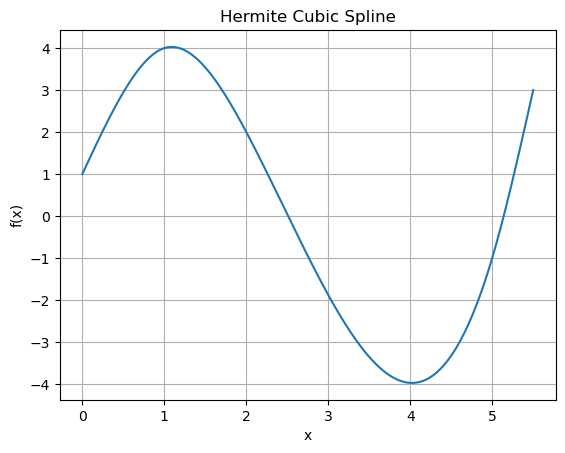

In [3]:
v = []

with open('out/spline.txt', 'r') as file:
    for line in file:
        v.append([float(n) for n in line.strip().split()])

N = 1000
x = np.linspace(v[0][0], v[-1][0], N)
y = np.zeros(N)

for i in range(len(v) - 1):
    x0 = v[i][0]
    x1 = v[i + 1][0]
    a = v[i][1]
    b = v[i][2]
    c = v[i][3]
    d = v[i][4]

    y[(x0 <= x) & (x < x1)] = (a +
        b * (x[(x0 <= x) & (x < x1)] - x0) +
        c * (x[(x0 <= x) & (x < x1)] - x0)**2 +
        d * (x[(x0 <= x) & (x < x1)] - x0)**3)

y[x == v[-1][0]] = [v[-1][1]]

plt.plot(x, y)
plt.title('Hermite Cubic Spline')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()